#  Clustering: KMeans
## USArrets dataset


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms


In [2]:
from statsmodels.datasets import get_rdataset
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


## Dataset
`USArrests`, a data set in the `R` computing environment.
We retrieve the data using `get_rdataset()`, which can fetch data from many standard `R` packages.

The rows of the data set contain the 50 states, in alphabetical order.

In [3]:
USArrests = get_rdataset('USArrests').data
USArrests.head()

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


The columns of the data set contain the four variables.

## $K$-Means Clustering


### Perfom the clustering

The goal in this section is to obtain `K` clusters.

Question: 
- Is neccesary to normalize these data?
- Complete the code to perform clustering with KMeans for  𝑘=4 and 𝑘=6 clusters.

In [4]:
# Kmeans K=4
kmeans4 = KMeans(n_clusters=4,
                random_state=3,
                n_init=20).fit(USArrests)

c:\Users\Public\miniforge3\envs\micro\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Visualize the results

Plot the data with each observation colored according to its cluster assignment by means scatter plots and include the centroids.

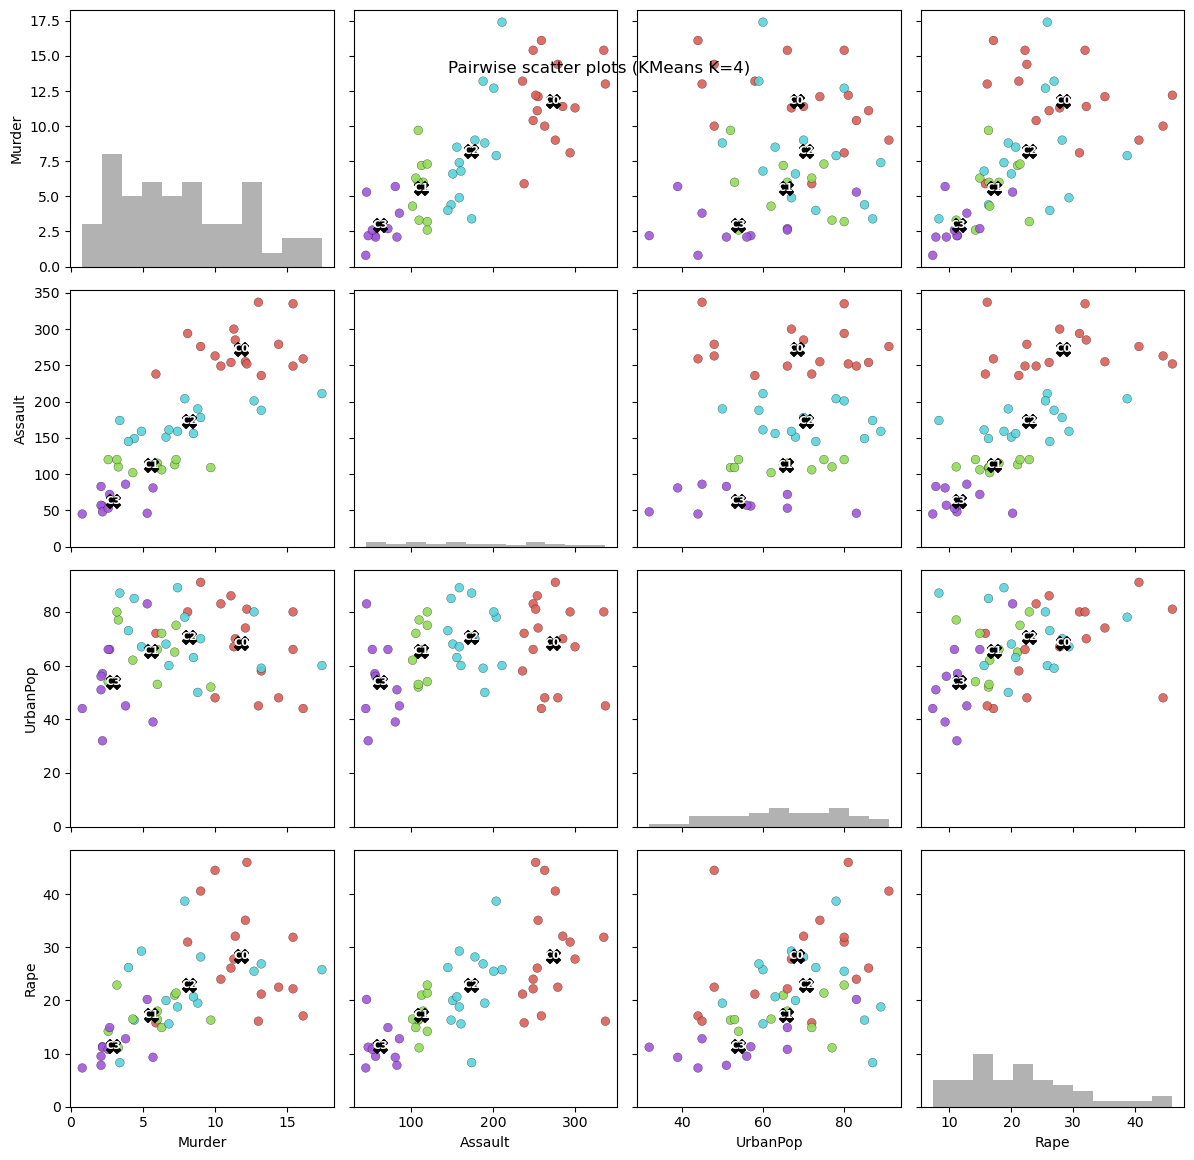

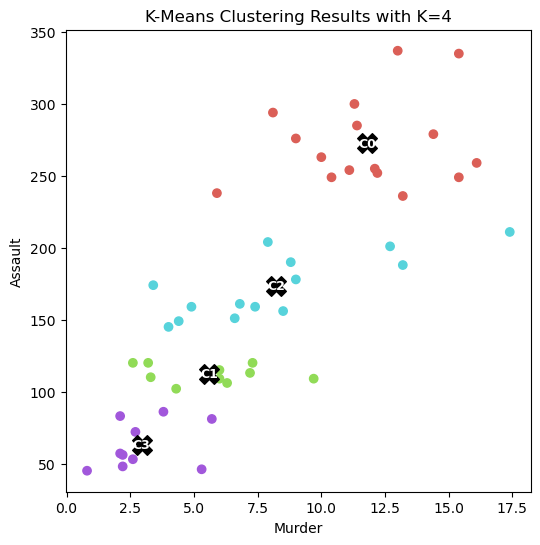

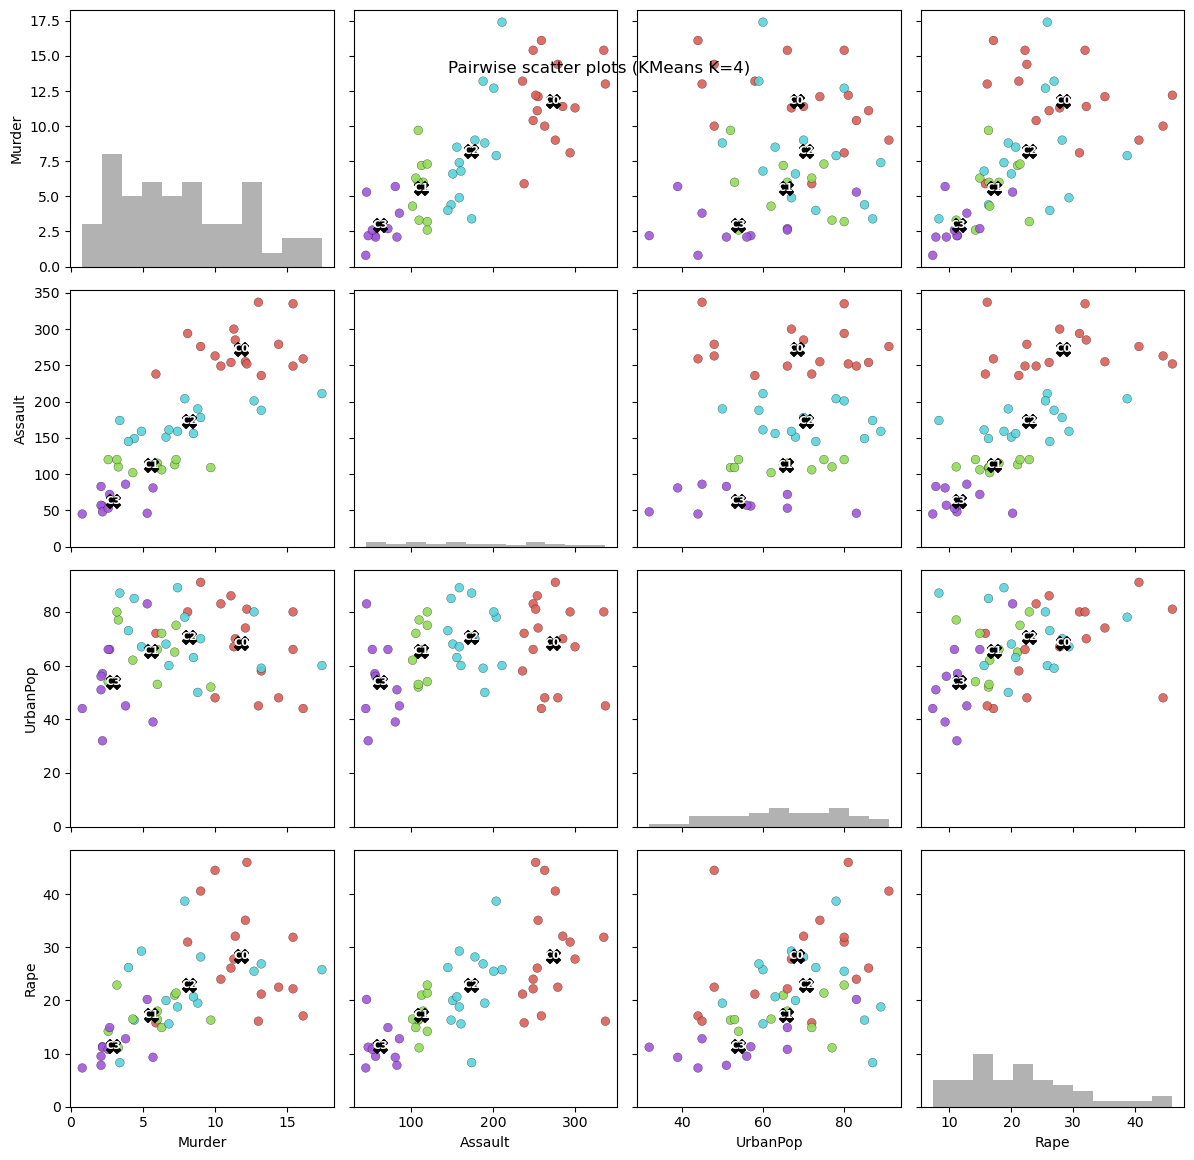

In [12]:
# Scatter plots between the variables
# Answer: Add your own code here
palette = sns.color_palette("hls", n_colors=kmeans4.n_clusters)
cluster_colors = [palette[label] for label in kmeans4.labels_]

fig, ax = plt.subplots(1, 1, figsize=(6,6))
# USArrests is a DataFrame -> use .iloc (or .values) instead of NumPy-style indexing
x = USArrests.iloc[:, 0].values  # Murder
y = USArrests.iloc[:, 1].values  # Assault
ax.scatter(x, y, c=cluster_colors)
ax.set_xlabel(USArrests.columns[0])
ax.set_ylabel(USArrests.columns[1])
ax.set_title("K-Means Clustering Results with K=4")
centers = kmeans4.cluster_centers_
ax.scatter(centers[:, 0], centers[:, 1], s=200, c='k', marker='X', zorder=10)
# centers has 4 columns; we only plotted the first two (Murder, Assault),
# so iterate over the first two columns to avoid unpacking errors.
for i, (cx, cy) in enumerate(centers[:, :2]):
    ax.annotate(f'C{i}', (cx, cy), color='white', weight='bold',
                ha='center', va='center', fontsize=9, zorder=11)
fig
# Pairwise scatter plots for all four variables (colored by kmeans4 clusters)
vars = USArrests.columns.tolist()
n = len(vars)

fig, axes = plt.subplots(n, n, figsize=(12, 12), sharex='col', sharey='row')
for i in range(n):
    for j in range(n):
        axp = axes[i, j]
        if i == j:
            # diagonal: histogram of the variable
            axp.hist(USArrests[vars[i]].values, bins=12, color='gray', alpha=0.6)
        else:
            # scatter plot of variable j (x) vs variable i (y)
            axp.scatter(USArrests[vars[j]].values, USArrests[vars[i]].values,
                        c=cluster_colors, s=40, edgecolor='k', linewidth=0.2, alpha=0.9)
            # plot centroids projected on the same pair of dimensions
            axp.scatter(centers[:, j], centers[:, i], c='k', marker='X', s=100, zorder=10)
            for k in range(centers.shape[0]):
                axp.annotate(f'C{k}', (centers[k, j], centers[k, i]),
                             color='white', weight='bold', ha='center', va='center',
                             fontsize=8, zorder=11)
        # only show outer labels to reduce clutter
        if i == n - 1:
            axp.set_xlabel(vars[j])
        else:
            axp.set_xlabel('')
        if j == 0:
            axp.set_ylabel(vars[i])
        else:
            axp.set_ylabel('')

plt.suptitle('Pairwise scatter plots (KMeans K=4)', y=0.92)
plt.tight_layout()
fig



### Repeat the Kmeans with K=6

c:\Users\Public\miniforge3\envs\micro\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


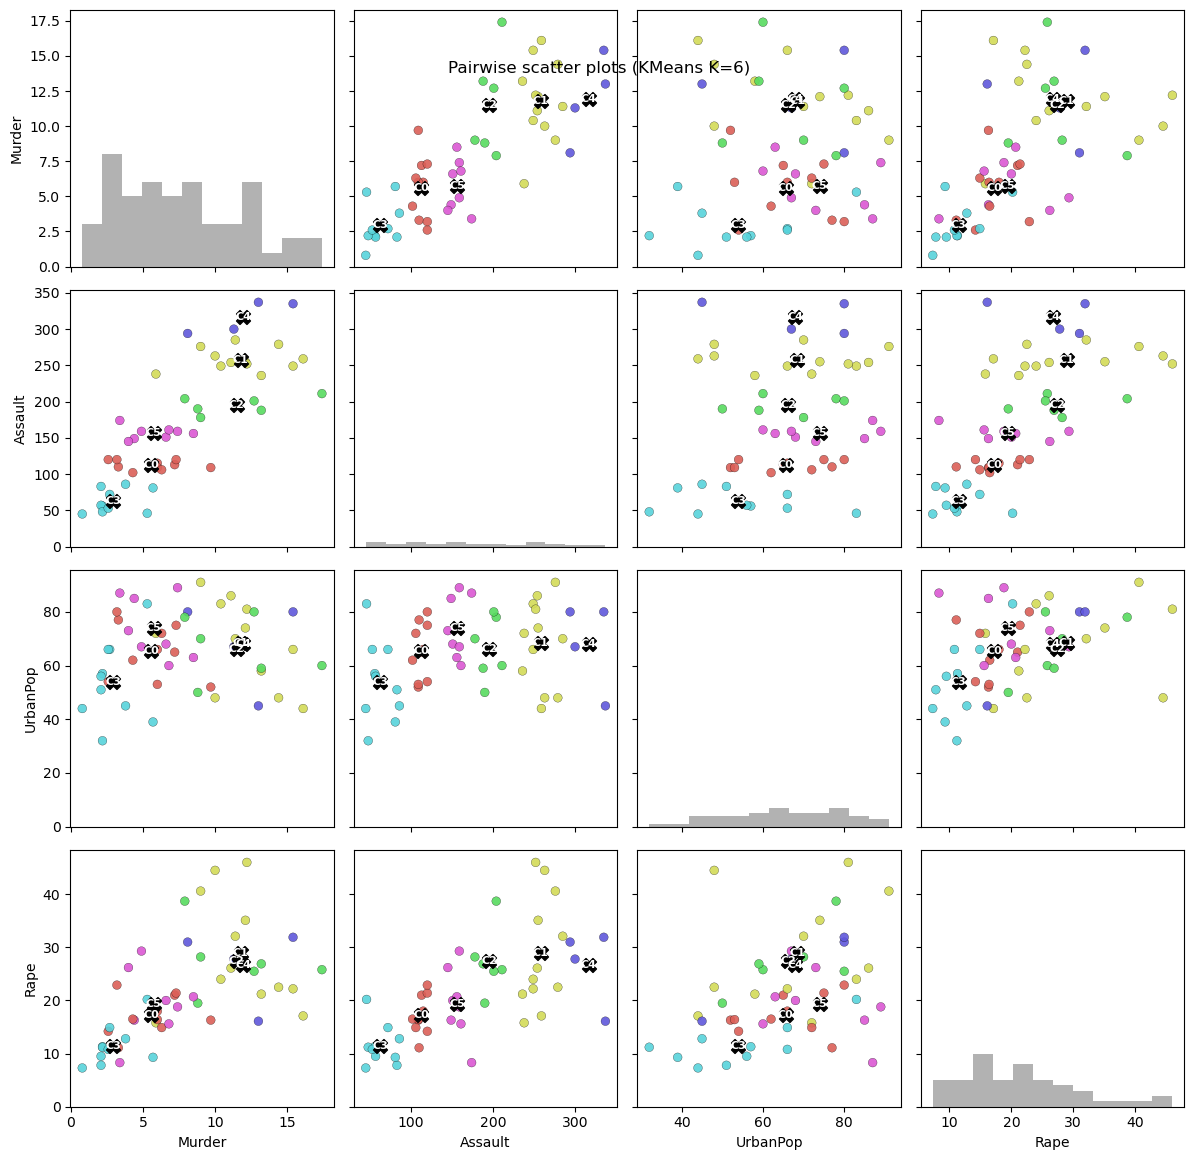

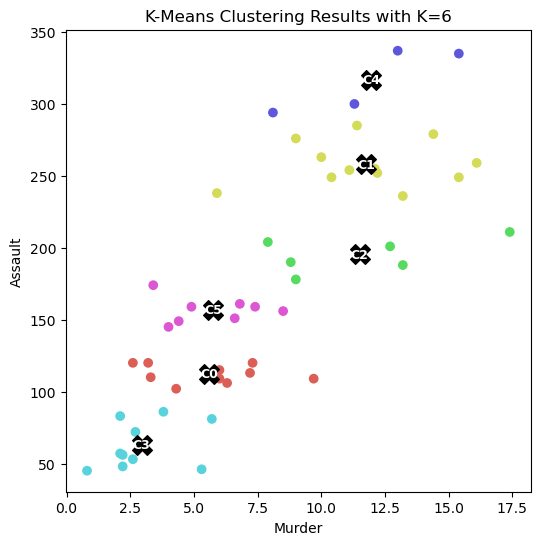

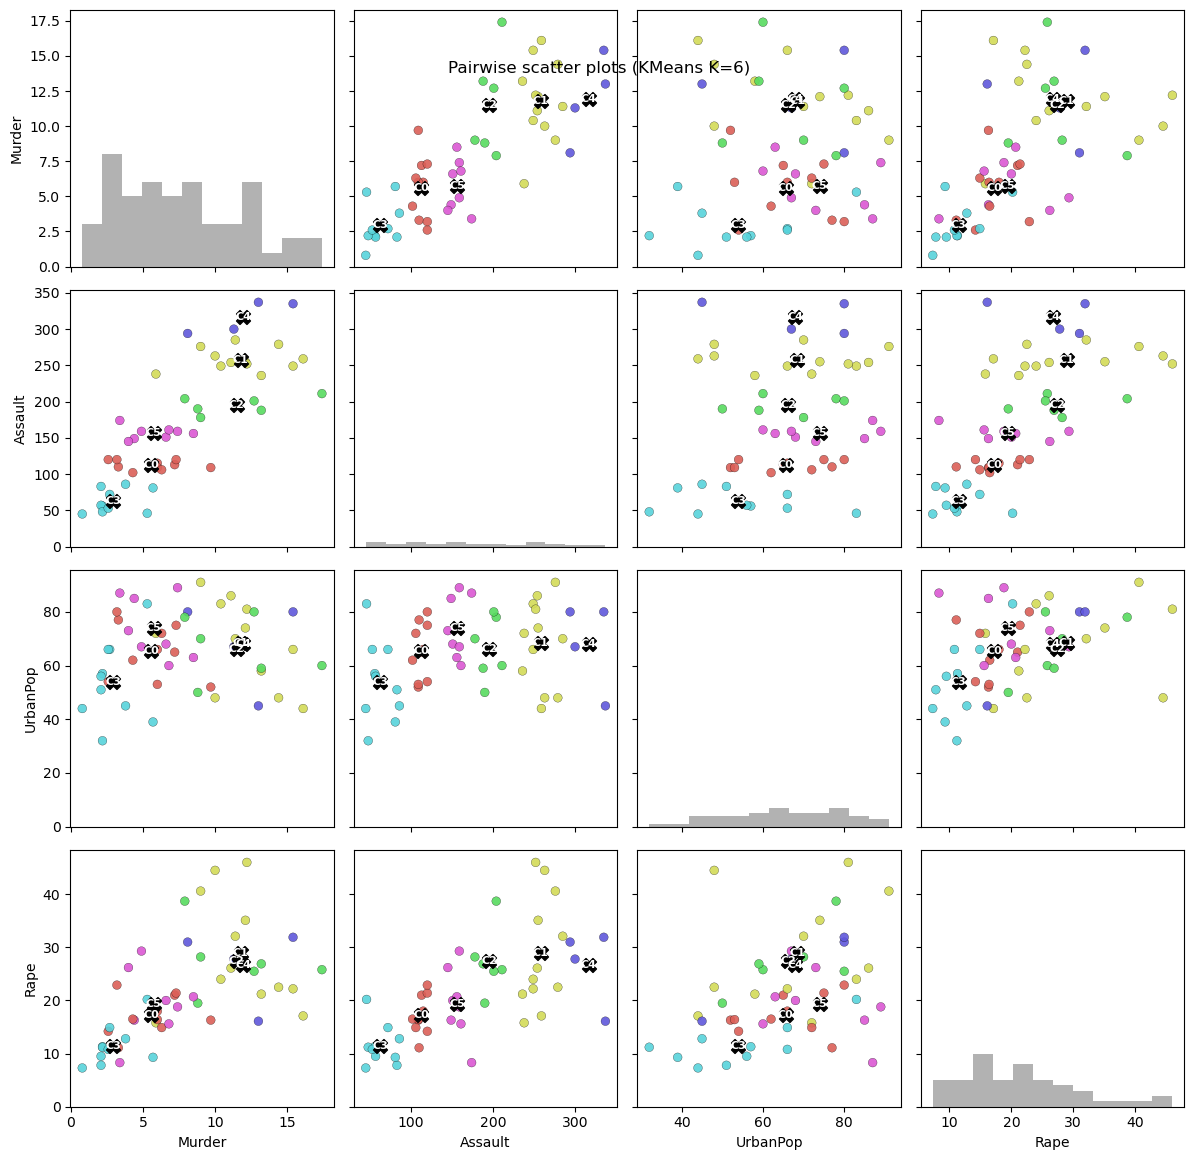

In [14]:
# Kmeans K=6
# Answer: Add your own code here
kmeans6 = KMeans(n_clusters=6,
                 random_state=3,
                 n_init=20).fit(USArrests)

# Scatter plots between the variables for K=6
palette6 = sns.color_palette("hls", n_colors=kmeans6.n_clusters)
cluster_colors6 = [palette6[label] for label in kmeans6.labels_]
centers6 = kmeans6.cluster_centers_

# Simple 2D scatter (first two variables)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
x6 = USArrests.iloc[:, 0].values  # Murder
y6 = USArrests.iloc[:, 1].values  # Assault
ax.scatter(x6, y6, c=cluster_colors6)
ax.set_xlabel(USArrests.columns[0])
ax.set_ylabel(USArrests.columns[1])
ax.set_title("K-Means Clustering Results with K=6")
ax.scatter(centers6[:, 0], centers6[:, 1], s=200, c='k', marker='X', zorder=10)
for i, (cx, cy) in enumerate(centers6[:, :2]):
    ax.annotate(f'C{i}', (cx, cy), color='white', weight='bold',
                ha='center', va='center', fontsize=9, zorder=11)
fig

# Pairwise scatter plots for all four variables (colored by kmeans6 clusters)
vars = USArrests.columns.tolist()
n = len(vars)

fig, axes = plt.subplots(n, n, figsize=(12, 12), sharex='col', sharey='row')
for i in range(n):
    for j in range(n):
        axp = axes[i, j]
        if i == j:
            axp.hist(USArrests[vars[i]].values, bins=12, color='gray', alpha=0.6)
        else:
            axp.scatter(USArrests[vars[j]].values, USArrests[vars[i]].values,
                        c=cluster_colors6, s=40, edgecolor='k', linewidth=0.2, alpha=0.9)
            # plot centroids projected on the same pair of dimensions
            axp.scatter(centers6[:, j], centers6[:, i], c='k', marker='X', s=100, zorder=10)
            for k in range(centers6.shape[0]):
                axp.annotate(f'C{k}', (centers6[k, j], centers6[k, i]),
                             color='white', weight='bold', ha='center', va='center',
                             fontsize=8, zorder=11)
        if i == n - 1:
            axp.set_xlabel(vars[j])
        else:
            axp.set_xlabel('')
        if j == 0:
            axp.set_ylabel(vars[i])
        else:
            axp.set_ylabel('')

plt.suptitle('Pairwise scatter plots (KMeans K=6)', y=0.92)
plt.tight_layout()
fig


### Analyze the optimal number of clusters

a) Based on the total within-cluster sum of squares

In [ ]:
# Answer: Add your own code here


b) Based on the silhoutte method

In [ ]:
# Answer: Add your own code here
silhouette4 = silhouette_score(USArrests, kmeans4.labels_)


### Visualize the optimal result

In [16]:
def plot_ellipse(ax, cluster_data, cluster_center, label, color):
    """
    Dibuja una elipse para un cluster en el gráfico dado.
    """
    cov = np.cov(cluster_data, rowvar=False)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ellipse_radius_x = np.sqrt(1 + pearson)
    ellipse_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ellipse_radius_x * 2, height=ellipse_radius_y * 2, edgecolor=color, facecolor='none')

    scale_x = np.sqrt(cov[0, 0]) * 2
    mean_x = cluster_center[0]

    scale_y = np.sqrt(cov[1, 1]) * 2
    mean_y = cluster_center[1]

    transf = transforms.Affine2D().rotate_deg(45).scale(scale_x, scale_y).translate(mean_x, mean_y)
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)
    ax.scatter(cluster_center[0], cluster_center[1], color=color, s=100, marker='X')
    ax.text(cluster_center[0], cluster_center[1], label, fontsize=12, ha='center', va='center', color=color)

